# WanderWise Module 2: K-Means Clustering + Rating Normalization

This notebook:
1. **Loads filtered places** from Module 1
2. **Performs K-Means clustering** to group places by day (using number of trip days as K)
3. **Normalizes ratings** within each cluster relative to the highest rating in that cluster
4. **Visualizes clusters** on an interactive map
5. **Exports normalized data** for Module 3 (Route Optimization)

## Workflow
```
Module 1 (Filtering) → Module 2 (Clustering + Normalization) → Module 3 (GA Route Optimization)
```

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import folium
from folium.plugins import MarkerCluster
import json
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

print('✓ All libraries loaded successfully!')

✓ All libraries loaded successfully!


## 1. Load Filtered Places from Module 1

In [2]:
# Load filtered places from Module 1
# This can be either CSV or JSON output from module1_preference_filtering.ipynb

# Try loading from CSV first
try:
    df = pd.read_csv('module1_filtered_places.csv')
    print("✓ Loaded filtered places from CSV")
except FileNotFoundError:
    # If CSV doesn't exist, load from original dataset
    print("⚠ Module 1 output not found. Loading full dataset as fallback...")
    df = pd.read_csv('goadataset.csv')
    # Apply basic filtering (rating >= 4.0)
    df = df[df['rating'] >= 3.0].copy()
    print(f"  Loaded {len(df)} places with rating >= 3.0")

print(f"\nDataset Info:")
print(f"  Total places: {len(df)}")
print(f"  Columns: {list(df.columns)}")
print(f"\nFirst 3 places:")
df.head(3)

✓ Loaded filtered places from CSV

Dataset Info:
  Total places: 464
  Columns: ['name', 'address', 'rating', 'user_ratings_total', 'place_id', 'types', 'taluka', 'latitude', 'longitude', 'Unnamed: 9', 'Unnamed: 10', 'categories']

First 3 places:


,name,address,rating,user_ratings_total,place_id,types,taluka,latitude,longitude,Unnamed: 9,Unnamed: 10,categories
0,Fort Aguada,"Fort Aguada Rd, Aguada Fort Area, Candolim, Go...",4.2,106573.0,ChIJa72MxnXBvzsRHHtpszB2g6M,"tourist_attraction, point_of_interest, establi...",Bardez (Mapusa),15.492252,73.773746,NaN,NaN,"['adventure', 'historical']"
1,Dudhsagar Falls,"Sonauli, Goa 403410, India",4.6,30982.0,ChIJQ4srFBimvzsRJQI7KOdIlP0,"tourist_attraction, point_of_interest, establi...",Sanguem,15.314438,74.314307,NaN,NaN,"['adventure', 'nature']"
2,Velsao Beach,"9V3M+QG9, Consua, Goa 403712, India",4.3,4971.0,ChIJY6h2EJ-3vzsRB_haiJ7F51w,"tourist_attraction, point_of_interest, establi...",Mormugao (Vasco),15.354423,73.883864,NaN,NaN,['beaches']


In [27]:
import pandas as pd
import json
from shapely.geometry import shape, Point

# ============================================
# 1. LOAD GOA BOUNDARY
# ============================================

with open('goa.geojson', 'r') as f:
    goa_boundary = shape(json.load(f)['features'][0]['geometry'])
print(f"✅ Loaded Goa boundary")

# ============================================
# 2. LOAD FULL DATA (before any filtering)
# ============================================

df_full = pd.read_csv('module1_filtered_places.csv')  # or 'goadataset.csv'
print(f"📊 Total places loaded: {len(df_full)}")

# ============================================
# 3. CHECK WHICH ARE INSIDE vs OUTSIDE
# ============================================

def check_location(row):
    """Returns True if inside Goa, False if outside"""
    try:
        point = Point(row['longitude'], row['latitude'])
        return goa_boundary.contains(point)
    except:
        return False

# Create boolean mask
df_full['inside_goa'] = df_full.apply(check_location, axis=1)

# ============================================
# 4. SEPARATE INSIDE vs OUTSIDE
# ============================================

df_inside = df_full[df_full['inside_goa'] == True].copy()
df_outside = df_full[df_full['inside_goa'] == False].copy()

print(f"\n✅ Inside Goa: {len(df_inside)} places")
print(f"❌ Outside Goa (REMOVED): {len(df_outside)} places")

# ============================================
# 5. INSPECT REMOVED PLACES
# ============================================

print(f"\n🔍 PLACES OUTSIDE GOA (showing first 10):")
print("=" * 60)

# Show key columns - adjust based on your data
display_cols = ['name', 'latitude', 'longitude', 'rating', 'types'] if 'types' in df_outside.columns else ['name', 'latitude', 'longitude', 'rating']

if len(df_outside) > 0:
    print(df_outside[display_cols].head(10).to_string())
    
    # Summary by rating
    print(f"\n📉 Removed places by rating:")
    print(df_outside['rating'].value_counts().sort_index(ascending=False))
    
    # Summary by type (if available)
    if 'types' in df_outside.columns:
        print(f"\n🏷️  Removed places by type:")
        # Flatten types if they're lists/strings
        type_list = df_outside['types'].explode() if df_outside['types'].dtype == 'object' else df_outside['types']
        print(type_list.value_counts().head(10))
else:
    print("No places outside Goa found!")

# ============================================
# 6. SAVE REMOVED PLACES FOR REVIEW
# ============================================

if len(df_outside) > 0:
    df_outside.drop(columns=['inside_goa'], inplace=True)
    df_outside.to_csv('places_OUTSIDE_Goa_REMOVED.csv', index=False)
    print(f"\n💾 Saved removed places to: places_OUTSIDE_Goa_REMOVED.csv")

# Clean up and save inside places
df_inside.drop(columns=['inside_goa'], inplace=True)
df_inside.to_csv('module1_filtered_places_GOA_ONLY.csv', index=False)
print(f"💾 Saved Goa places to: module1_filtered_places_GOA_ONLY.csv")

# ============================================
# 7. VISUAL BOUNDS CHECK (optional debug)
# ============================================

print(f"\n📍 BOUNDS COMPARISON:")
print(f"Goa boundary:     {goa_boundary.bounds}")  # (min_lon, min_lat, max_lon, max_lat)
print(f"Inside places:    ({df_inside['longitude'].min():.3f}, {df_inside['latitude'].min():.3f}, {df_inside['longitude'].max():.3f}, {df_inside['latitude'].max():.3f})")
if len(df_outside) > 0:
    print(f"Outside places:   ({df_outside['longitude'].min():.3f}, {df_outside['latitude'].min():.3f}, {df_outside['longitude'].max():.3f}, {df_outside['latitude'].max():.3f})")

✅ Loaded Goa boundary
📊 Total places loaded: 486

✅ Inside Goa: 464 places
❌ Outside Goa (REMOVED): 22 places

🔍 PLACES OUTSIDE GOA (showing first 10):
                                       name   latitude  longitude  rating                                                       types
110                             Yellur Fort  15.757090  74.526499     4.5        tourist_attraction, point_of_interest, establishment
118           Yashwant Gad Fort , Redi Fort  15.752647  73.664741     4.6        tourist_attraction, point_of_interest, establishment
119                           Belagavi Fort  15.859388  74.524359     4.4        tourist_attraction, point_of_interest, establishment
194              Bhimgad Wildlife Sanctuary  15.564871  74.335286     4.4                      park, point_of_interest, establishment
367                             Pargad Fort  15.816922  74.044998     4.6                            point_of_interest, establishment
369                               Moti Lake 

## 2. Trip Configuration

In [3]:
# CONFIGURATION - Modify these parameters
NUM_DAYS = 4  # Number of days for the trip (K for clustering)
MAX_PLACES_PER_DAY = 15  # Maximum places to visit per day
MIN_RATING = 3.0  # Minimum rating threshold (lowered to 3.0)
MIN_REVIEWS = 1  # Minimum reviews for credibility (Bayesian prior)

print("Trip Configuration:")
print(f"  Number of Days: {NUM_DAYS}")
print(f"  Max Places/Day: {MAX_PLACES_PER_DAY}")
print(f"  Min Rating: {MIN_RATING}")
print(f"  Min Reviews (Bayesian prior): {MIN_REVIEWS}")
print(f"  Total Places Available: {len(df)}")

# Apply rating filter
df = df[df['rating'] >= MIN_RATING].copy()
print(f"  After rating filter (>= {MIN_RATING}): {len(df)} places")

# Ensure we have at least NUM_DAYS places
if len(df) < NUM_DAYS:
    raise ValueError(f"Not enough places ({len(df)}) for {NUM_DAYS} days. Need at least {NUM_DAYS} places.")

Trip Configuration:
  Number of Days: 4
  Max Places/Day: 15
  Min Rating: 3.0
  Min Reviews (Bayesian prior): 1
  Total Places Available: 464
  After rating filter (>= 3.0): 464 places


## 3. Prepare Data for Clustering

In [4]:
# Extract coordinates and metadata
coordinates = df[['latitude', 'longitude']].values
location_names = df['name'].tolist()
ratings = df['rating'].values
rating_count = df['user_ratings_total'].values
place_ids = df['place_id'].tolist() if 'place_id' in df.columns else list(range(len(df)))

print(f"Prepared data for clustering:")
print(f"  Coordinates shape: {coordinates.shape}")
print(f"  Number of locations: {len(location_names)}")
print(f"  Rating range: {ratings.min():.1f} - {ratings.max():.1f}")
print(f"User Rating: {rating_count.sum()}")
print(f"  Average rating: {ratings.mean():.2f}")

Prepared data for clustering:
  Coordinates shape: (464, 2)
  Number of locations: 464
  Rating range: 3.0 - 5.0
User Rating: 931700.0
  Average rating: 4.37


## 4. Perform K-Means Clustering

Group places into clusters based on geographical proximity. Each cluster represents a day of the trip.

In [5]:
def perform_kmeans_clustering(coords, num_clusters, random_state=42):
    """
    Perform K-Means clustering on coordinates.
    
    Args:
        coords: numpy array of shape (n, 2) with [latitude, longitude]
        num_clusters: number of clusters (K)
        random_state: random seed for reproducibility
    
    Returns:
        labels: array of cluster labels
        centroids: array of cluster centroids
        kmeans: fitted KMeans object
    """
    print(f"\n⏳ Performing K-Means clustering (K={num_clusters})...")
    
    kmeans = KMeans(
        n_clusters=num_clusters,
        random_state=random_state,
        n_init=10,
        max_iter=300
    )
    
    labels = kmeans.fit_predict(coords)
    centroids = kmeans.cluster_centers_
    
    print("✅ Clustering complete!")
    print(f"   Inertia (within-cluster sum of squares): {kmeans.inertia_:.2f}")
    
    return labels, centroids, kmeans

# Perform clustering
cluster_labels, cluster_centroids, kmeans_model = perform_kmeans_clustering(
    coordinates,
    NUM_DAYS
)

# Add cluster labels to dataframe
df['cluster'] = cluster_labels
df['day'] = cluster_labels + 1  # Day numbering starts from 1


⏳ Performing K-Means clustering (K=4)...
✅ Clustering complete!
   Inertia (within-cluster sum of squares): 5.92


In [6]:
# Display clustering statistics
print("\n" + "="*70)
print("📊 CLUSTERING RESULTS")
print("="*70)

for day in range(1, NUM_DAYS + 1):
    day_places = df[df['day'] == day]
    cluster_idx = day - 1
    
    print(f"\n📅 Day {day} (Cluster {cluster_idx})")
    print(f"   {'-'*66}")
    print(f"   Places to visit: {len(day_places)}")
    print(f"   Centroid: ({cluster_centroids[cluster_idx][0]:.6f}, {cluster_centroids[cluster_idx][1]:.6f})")
    print(f"   Average rating: {day_places['rating'].mean():.2f}")
    print(f"   Rating range: {day_places['rating'].min():.1f} - {day_places['rating'].max():.1f}")
    print(f"\n   Places:")
    
    for idx, row in day_places.iterrows():
        print(f"      • {row['name'][:50]:50s} | Rating: {row['rating']:.1f}")

print("\n" + "="*70)


📊 CLUSTERING RESULTS

📅 Day 1 (Cluster 0)
   ------------------------------------------------------------------
   Places to visit: 205
   Centroid: (15.524383, 73.821773)
   Average rating: 4.30
   Rating range: 3.0 - 5.0

   Places:
      • Fort Aguada                                        | Rating: 4.2
      • Chapora Fort                                       | Rating: 4.2
      • Basilica of Bom Jesus                              | Rating: 4.5
      • Se Cathedral                                       | Rating: 4.5
      • Sinquerim Fort                                     | Rating: 4.5
      • Dona Paula View Point                              | Rating: 4.1
      • St. Augustine Tower                                | Rating: 4.5
      • Candolim Beach                                     | Rating: 4.5
      • Adil Shah Palace Gateway                           | Rating: 4.1
      • Dona Paula Jetty Goa                               | Rating: 4.3
      • Calangute Beach, Goa      

## 5. Calculate POI Popularity Score (Based on Module II Research)

### Research Background: WanderWise+ Popularity Index (WPI)

According to Module II research, the full WPI formula is:
```
WPI(poi) = α × R(poi) + β × E(poi) + γ × T(poi) + δ × G(poi)
```
Where:
- **R** = Review-based score (35% weight)
- **E** = Engagement score (25% weight) - social media, photos
- **T** = Temporal score (25% weight) - seasonality, trends  
- **G** = Geographic score (15% weight) - clustering, accessibility

### Simplified Implementation (Google Data Only)

Since we only have Google Places data (rating + review count), we implement a **simplified Review-based (R) score**:

#### Step 1: Normalize Google Rating (0-1 scale)
```python
normalized_rating = (google_rating - 1) / 4  # Maps 1-5 to 0-1
```

#### Step 2: Calculate Quantity Factor (logarithmic)
```python
quantity_factor = log(1 + review_count) / log(1 + max_review_count_in_cluster)
```

#### Step 3: Bayesian Weighted Rating (credibility adjustment)
```python
weighted_rating = (v / (v + m)) × R + (m / (v + m)) × C
```
Where:
- `v` = user_ratings_total (review count)
- `m` = confidence threshold (default: 100)
- `R` = normalized rating (0-1)
- `C` = global mean rating (0-1)

#### Step 4: Popularity Score (combines quality + quantity)
```python
popularity_score = 0.7 × weighted_rating + 0.3 × quantity_factor
```

This balances:
- **70% Quality** (rating adjusted for credibility)
- **30% Popularity** (review volume)

### Why This Approach?

✅ **Follows Module II principles**: Multi-factor scoring, logarithmic quantity handling, Bayesian credibility  
✅ **Adapts to available data**: Uses only Google rating + review count  
✅ **Prevents biases**: High rating + low reviews → conservative score  
✅ **Cluster-ready**: Will normalize within clusters next

In [7]:
def calculate_popularity_score(df_with_clusters, min_reviews=100):
    """
    Calculate POI popularity score following Module II WPI research framework.
    Simplified implementation using only Google Places data (rating + review count).
    
    Based on WPI formula: WPI = α×R + β×E + γ×T + δ×G
    This implements the Review-based (R) component with:
      - Quality factor: Bayesian weighted rating (credibility-adjusted)
      - Quantity factor: Logarithmic review count (diminishing returns)
    
    Args:
        df_with_clusters: DataFrame with 'cluster', 'rating', 'user_ratings_total'
        min_reviews: Bayesian confidence parameter (default: 100)
    
    Returns:
        DataFrame with added popularity scoring columns
    """
    print("\n⏳ Calculating POI popularity scores (Module II WPI framework)...")
    print("   Based on: Review Quality (70%) + Review Quantity (30%)")
    
    df_pop = df_with_clusters.copy()
    
    # Step 1: Normalize Google rating to 0-1 scale (Module II method)
    df_pop['normalized_google_rating'] = (df_pop['rating'] - 1) / 4
    
    # Step 2: Calculate global mean (for Bayesian prior)
    global_mean_rating = df_pop['rating'].mean()
    global_mean_normalized = (global_mean_rating - 1) / 4
    
    # Step 3: Bayesian weighted rating (credibility adjustment)
    v = df_pop['user_ratings_total']  # Number of reviews
    m = min_reviews  # Confidence threshold
    R = df_pop['normalized_google_rating']  # Normalized rating
    C = global_mean_normalized  # Global mean (Bayesian prior)
    
    df_pop['weighted_rating'] = (v / (v + m)) * R + (m / (v + m)) * C
    
    # Step 4: Calculate quantity factor per cluster (logarithmic)
    # Uses cluster-specific max to ensure fair comparison within each day
    cluster_max_reviews = df_pop.groupby('cluster')['user_ratings_total'].transform('max')
    df_pop['quantity_factor'] = np.log1p(df_pop['user_ratings_total']) / np.log1p(cluster_max_reviews)
    
    # Step 5: Combined popularity score (70% quality, 30% quantity)
    # Weights follow Module II research: quality dominates but quantity matters
    QUALITY_WEIGHT = 0.6
    QUANTITY_WEIGHT = 0.4
    
    df_pop['popularity_score'] = (
        QUALITY_WEIGHT * df_pop['weighted_rating'] + 
        QUANTITY_WEIGHT * df_pop['quantity_factor']
    )
    
    print(f"✅ Popularity scores calculated!")
    print(f"   Global mean rating: {global_mean_rating:.2f} stars")
    print(f"   Normalized mean: {global_mean_normalized:.3f}")
    print(f"   Bayesian confidence parameter (m): {min_reviews}")
    print(f"   Quality weight: {QUALITY_WEIGHT:.1%}, Quantity weight: {QUANTITY_WEIGHT:.1%}")
    
    return df_pop, global_mean_rating

# Calculate popularity scores
df_with_popularity, global_mean = calculate_popularity_score(df, MIN_REVIEWS)


⏳ Calculating POI popularity scores (Module II WPI framework)...
   Based on: Review Quality (70%) + Review Quantity (30%)
✅ Popularity scores calculated!
   Global mean rating: 4.37 stars
   Normalized mean: 0.842
   Bayesian confidence parameter (m): 1
   Quality weight: 60.0%, Quantity weight: 40.0%


## 6. Normalize Popularity Scores Within Each Cluster

Following Module II research: Normalize popularity scores within clusters for fair day comparison.

In [8]:
def normalize_popularity_by_cluster(df_with_popularity):
    """
    Normalize popularity scores within each cluster (Module II WPI approach).
    
    Args:
        df_with_popularity: DataFrame with 'cluster' and 'popularity_score' columns
    
    Returns:
        DataFrame with added 'normalized_popularity' column
    """
    print("\n⏳ Normalizing popularity scores within clusters...")
    
    df_normalized = df_with_popularity.copy()
    
    # Calculate max popularity score per cluster
    cluster_max_popularity = df_normalized.groupby('cluster')['popularity_score'].transform('max')
    
    # Normalize: best place in each cluster = 1.0
    df_normalized['cluster_max_popularity'] = cluster_max_popularity
    df_normalized['normalized_popularity'] = df_normalized['popularity_score'] / df_normalized['cluster_max_popularity']
    
    print("✅ Normalization complete!")
    
    # Display statistics
    print("\n" + "="*80)
    print("📊 MODULE II WPI: NORMALIZED POPULARITY STATISTICS")
    print("="*80)
    
    for day in sorted(df_normalized['day'].unique()):
        day_data = df_normalized[df_normalized['day'] == day].copy()
        
        print(f"\n📅 Day {day}:")
        print(f"   Places in cluster: {len(day_data)}")
        print(f"   Max popularity in cluster: {day_data['cluster_max_popularity'].iloc[0]:.3f}")
        print(f"   Normalized range: {day_data['normalized_popularity'].min():.3f} - {day_data['normalized_popularity'].max():.3f}")
        print(f"   Avg normalized popularity: {day_data['normalized_popularity'].mean():.3f}")
        print(f"\n   🏆 Top 5 attractions by WPI (quality + popularity):")
        print(f"   {'-'*76}")
        
        top_5 = day_data.nlargest(20, 'normalized_popularity')
        for i, (idx, row) in enumerate(top_5.iterrows(), 1):
            quality_pct = row['weighted_rating'] * 100  # Quality component
            quantity_pct = row['quantity_factor'] * 100  # Quantity component
            print(f"   {i}. {row['name'][:40]:40s}")
            print(f"      Rating: {row['rating']:.1f}★ ({row['user_ratings_total']:,} reviews) | "
                  f"Quality: {quality_pct:.1f}% | Quantity: {quantity_pct:.1f}% | "
                  f"WPI: {row['normalized_popularity']:.3f}")
    
    print("\n" + "="*80)
    
    return df_normalized

# Apply normalization
df_normalized = normalize_popularity_by_cluster(df_with_popularity)


⏳ Normalizing popularity scores within clusters...
✅ Normalization complete!

📊 MODULE II WPI: NORMALIZED POPULARITY STATISTICS

📅 Day 1:
   Places in cluster: 205
   Max popularity in cluster: 0.908
   Normalized range: 0.447 - 1.000
   Avg normalized popularity: 0.757

   🏆 Top 5 attractions by WPI (quality + popularity):
   ----------------------------------------------------------------------------
   1. Basilica of Bom Jesus                   
      Rating: 4.5★ (66,043.0 reviews) | Quality: 87.5% | Quantity: 95.9% | WPI: 1.000
   2. Candolim Beach                          
      Rating: 4.5★ (42,536.0 reviews) | Quality: 87.5% | Quantity: 92.1% | WPI: 0.983
   3. Calangute Beach, Goa                    
      Rating: 4.3★ (100,672.0 reviews) | Quality: 82.5% | Quantity: 99.5% | WPI: 0.983
   4. BENZ WAX MUSEUM & FISH AQUARIUM         
      Rating: 4.6★ (27,315.0 reviews) | Quality: 90.0% | Quantity: 88.2% | WPI: 0.983
   5. Fort Aguada                             
      Rating:

## 7. Visualize Clusters on Interactive Map

In [9]:
def create_cluster_map(df_clustered, centroids, title="K-Means Clustering Results"):
    """
    Create an interactive Folium map showing clustered places.
    
    Args:
        df_clustered: DataFrame with cluster assignments and normalized ratings
        centroids: Array of cluster centroids
        title: Map title
    
    Returns:
        Folium map object
    """
    # Calculate map center
    center_lat = df_clustered['latitude'].mean()
    center_lon = df_clustered['longitude'].mean()
    
    # Create map
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=10,
        tiles='OpenStreetMap'
    )
    
    # Color scheme for different days
    day_colors = {
        1: 'red',
        2: 'blue',
        3: 'green',
        4: 'purple',
        5: 'orange',
        6: 'darkred',
        7: 'lightred',
        8: 'beige',
        9: 'darkblue',
        10: 'darkgreen'
    }
    
    # Add markers for each place
    for idx, row in df_clustered.iterrows():
        day = row['day']
        color = day_colors.get(day, 'gray')
        
        # Create popup with WPI popularity score info
        popup_html = f"""
        <div style="font-family: Arial; width: 280px;">
            <h4 style="margin: 0; color: {color};">{row['name']}</h4>
            <hr style="margin: 5px 0;">
            <p style="margin: 3px 0;"><b>📅 Day {day}</b></p>
            <p style="margin: 3px 0;">⭐ Original: <b>{row['rating']:.1f}</b> ({int(row['user_ratings_total'])} reviews)</p>
            <p style="margin: 3px 0;">📊 WPI Score: <b>{row['normalized_popularity']:.3f}</b></p>
            <p style="margin: 3px 0; font-size: 10px;">Weighted: {row['weighted_rating']:.3f} | Quantity: {row['quantity_factor']:.3f}</p>
            <p style="margin: 5px 0; font-size: 10px;">📍 {row['latitude']:.6f}, {row['longitude']:.6f}</p>
        </div>
        """
        
        # Marker icon varies by WPI normalized popularity
        if row['normalized_popularity'] >= 0.95:
            icon = 'star'  # Best places
        elif row['normalized_popularity'] >= 0.85:
            icon = 'heart'  # Very good
        else:
            icon = 'map-marker'  # Good
        
        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=folium.Popup(popup_html, max_width=300),
            tooltip=f"Day {day}: {row['name']}",
            icon=folium.Icon(color=color, icon=icon, prefix='fa')
        ).add_to(m)
    
    # Add centroid markers
    for day in range(1, len(centroids) + 1):
        centroid = centroids[day - 1]
        color = day_colors.get(day, 'gray')
        
        centroid_html = f"""
        <div style="font-family: Arial;">
            <h4 style="margin: 0;">Day {day} Center</h4>
            <p style="margin: 5px 0; font-size: 11px;">📍 {centroid[0]:.6f}, {centroid[1]:.6f}</p>
        </div>
        """
        
        folium.Marker(
            location=[centroid[0], centroid[1]],
            popup=folium.Popup(centroid_html, max_width=200),
            icon=folium.Icon(color=color, icon='certificate', prefix='fa'),
            tooltip=f"Day {day} Centroid"
        ).add_to(m)
    
    # Add legend
    num_days = df_clustered['day'].nunique()
    num_places = len(df_clustered)
    
    legend_html = f'''
    <div style="position: fixed; 
                top: 10px; left: 50px; width: 280px;
                background-color: white; z-index: 1000;
                border: 2px solid grey; border-radius: 5px;
                padding: 12px; font-family: Arial;">
        <h4 style="margin: 0 0 10px 0;">🗺️ {title}</h4>
        <p style="margin: 5px 0; font-size: 12px;">
            📍 Total Places: {num_places}<br>
            📅 Days: {num_days}<br>
            ⭐ Avg Rating: {df_clustered['rating'].mean():.2f}
        </p>
        <hr style="margin: 10px 0;">
        <p style="margin: 0; font-size: 11px;">
            <b>Legend:</b><br>
            ⭐ Star = Top rated (normalized ≥ 0.95)<br>
            ❤️ Heart = Very good (≥ 0.85)<br>
            📍 Marker = Good places<br>
            🏆 Badge = Day center
        </p>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    return m

# Create and display map
print("\n🗺️ Generating interactive map...")
cluster_map = create_cluster_map(
    df_normalized,
    cluster_centroids,
    title=f"{NUM_DAYS}-Day Goa Trip Clusters"
)

# Save map
map_filename = 'module2_clustered_places_map.html'
cluster_map.save(map_filename)
print(f"✅ Map saved to: {map_filename}")

# Display in notebook
cluster_map


🗺️ Generating interactive map...
✅ Map saved to: module2_clustered_places_map.html


## 8. Export Clustered and Normalized Data

In [10]:
# Export to CSV
output_csv = 'module2_clustered_normalized_places.csv'
df_normalized.to_csv(output_csv, index=False)
print(f"✅ Exported to CSV: {output_csv}")

# Export to JSON for API/GA use
output_json = 'module2_clusters_for_ga.json'

# Create structured JSON for Genetic Algorithm
clusters_data = {
    "trip_id": f"trip_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
    "metadata": {
        "num_days": NUM_DAYS,
        "num_locations": len(df_normalized),
        "timestamp": datetime.now().isoformat(),
        "created_by": "module2_clustering_normalization"
    },
    "clusters": {},
    "centroids": cluster_centroids.tolist(),
    "day_details": {}
}

# Organize data by day/cluster
for day in range(1, NUM_DAYS + 1):
    day_places = df_normalized[df_normalized['day'] == day]
    
    # Create cluster index mapping
    clusters_data['clusters'][str(day)] = day_places.index.tolist()
    
    # Create detailed day information with WPI scores
    places_list = []
    for idx, row in day_places.iterrows():
        place_dict = {
            "id": row.get('place_id', idx),
            "name": row['name'],
            "latitude": float(row['latitude']),
            "longitude": float(row['longitude']),
            "rating": float(row['rating']),
            "user_ratings_total": int(row.get('user_ratings_total', 0)),
            "weighted_rating": float(row['weighted_rating']),
            "quantity_factor": float(row['quantity_factor']),
            "popularity_score": float(row['popularity_score']),
            "normalized_popularity": float(row['normalized_popularity']),
            "address": row.get('address', '')
        }
        places_list.append(place_dict)
    
    clusters_data['day_details'][str(day)] = {
        "cluster_id": day - 1,
        "num_places": len(day_places),
        "centroid": cluster_centroids[day - 1].tolist(),
        "avg_rating": float(day_places['rating'].mean()),
        "avg_weighted_rating": float(day_places['weighted_rating'].mean()),
        "avg_normalized_popularity": float(day_places['normalized_popularity'].mean()),
        "max_popularity": float(day_places['cluster_max_popularity'].iloc[0]),
        "places": places_list
    }

# Save JSON
with open(output_json, 'w') as f:
    json.dump(clusters_data, f, indent=2)

print(f"✅ Exported to JSON: {output_json}")
print(f"\n📦 Data structure for Genetic Algorithm:")
print(f"   - {NUM_DAYS} days")
print(f"   - {len(df_normalized)} total places")
print(f"   - Normalized ratings within each cluster")
print(f"   - Ready for Module 3 (Route Optimization)")

✅ Exported to CSV: module2_clustered_normalized_places.csv
✅ Exported to JSON: module2_clusters_for_ga.json

📦 Data structure for Genetic Algorithm:
   - 4 days
   - 464 total places
   - Normalized ratings within each cluster
   - Ready for Module 3 (Route Optimization)


## 9. Summary and Statistics

In [11]:
print("\n" + "="*70)
print("📊 MODULE 2 SUMMARY")
print("="*70)

print(f"\n📅 Trip Configuration:")
print(f"   Duration: {NUM_DAYS} days")
print(f"   Total places: {len(df_normalized)}")
print(f"   Avg places per day: {len(df_normalized) / NUM_DAYS:.1f}")

print(f"\n⭐ WPI Popularity Statistics:")
print(f"   Original rating range: {df_normalized['rating'].min():.1f} - {df_normalized['rating'].max():.1f}")
print(f"   Original avg rating: {df_normalized['rating'].mean():.2f}")
print(f"   Weighted rating range: {df_normalized['weighted_rating'].min():.3f} - {df_normalized['weighted_rating'].max():.3f}")
print(f"   Normalized popularity range: {df_normalized['normalized_popularity'].min():.3f} - {df_normalized['normalized_popularity'].max():.3f}")
print(f"   Avg normalized popularity: {df_normalized['normalized_popularity'].mean():.3f}")

print(f"\n📍 Clustering Quality:")
print(f"   K-Means inertia: {kmeans_model.inertia_:.2f}")
print(f"   Number of clusters: {NUM_DAYS}")

print(f"\n📊 Day-wise Breakdown:")
for day in range(1, NUM_DAYS + 1):
    day_data = df_normalized[df_normalized['day'] == day]
    print(f"   Day {day}: {len(day_data):2d} places | "
          f"Avg Rating: {day_data['rating'].mean():.2f} | "
          f"Avg WPI: {day_data['normalized_popularity'].mean():.3f}")

print(f"\n💾 Output Files:")
print(f"   1. {output_csv}")
print(f"   2. {output_json}")
print(f"   3. {map_filename}")

print(f"\n✅ Module 2 Complete!")
print(f"   Ready for Module 3: Genetic Algorithm Route Optimization")
print("="*70)


📊 MODULE 2 SUMMARY

📅 Trip Configuration:
   Duration: 4 days
   Total places: 464
   Avg places per day: 116.0

⭐ WPI Popularity Statistics:
   Original rating range: 3.0 - 5.0
   Original avg rating: 4.37
   Weighted rating range: 0.545 - 0.999
   Normalized popularity range: 0.447 - 1.000
   Avg normalized popularity: 0.755

📍 Clustering Quality:
   K-Means inertia: 5.92
   Number of clusters: 4

📊 Day-wise Breakdown:
   Day 1: 205 places | Avg Rating: 4.30 | Avg WPI: 0.757
   Day 2: 86 places | Avg Rating: 4.48 | Avg WPI: 0.746
   Day 3: 73 places | Avg Rating: 4.43 | Avg WPI: 0.713
   Day 4: 100 places | Avg Rating: 4.36 | Avg WPI: 0.790

💾 Output Files:
   1. module2_clustered_normalized_places.csv
   2. module2_clusters_for_ga.json
   3. module2_clustered_places_map.html

✅ Module 2 Complete!
   Ready for Module 3: Genetic Algorithm Route Optimization


## 10. Visualization: Weighted Rating vs Normalized Rating


✅ Analysis visualization saved to: module2_analysis.png


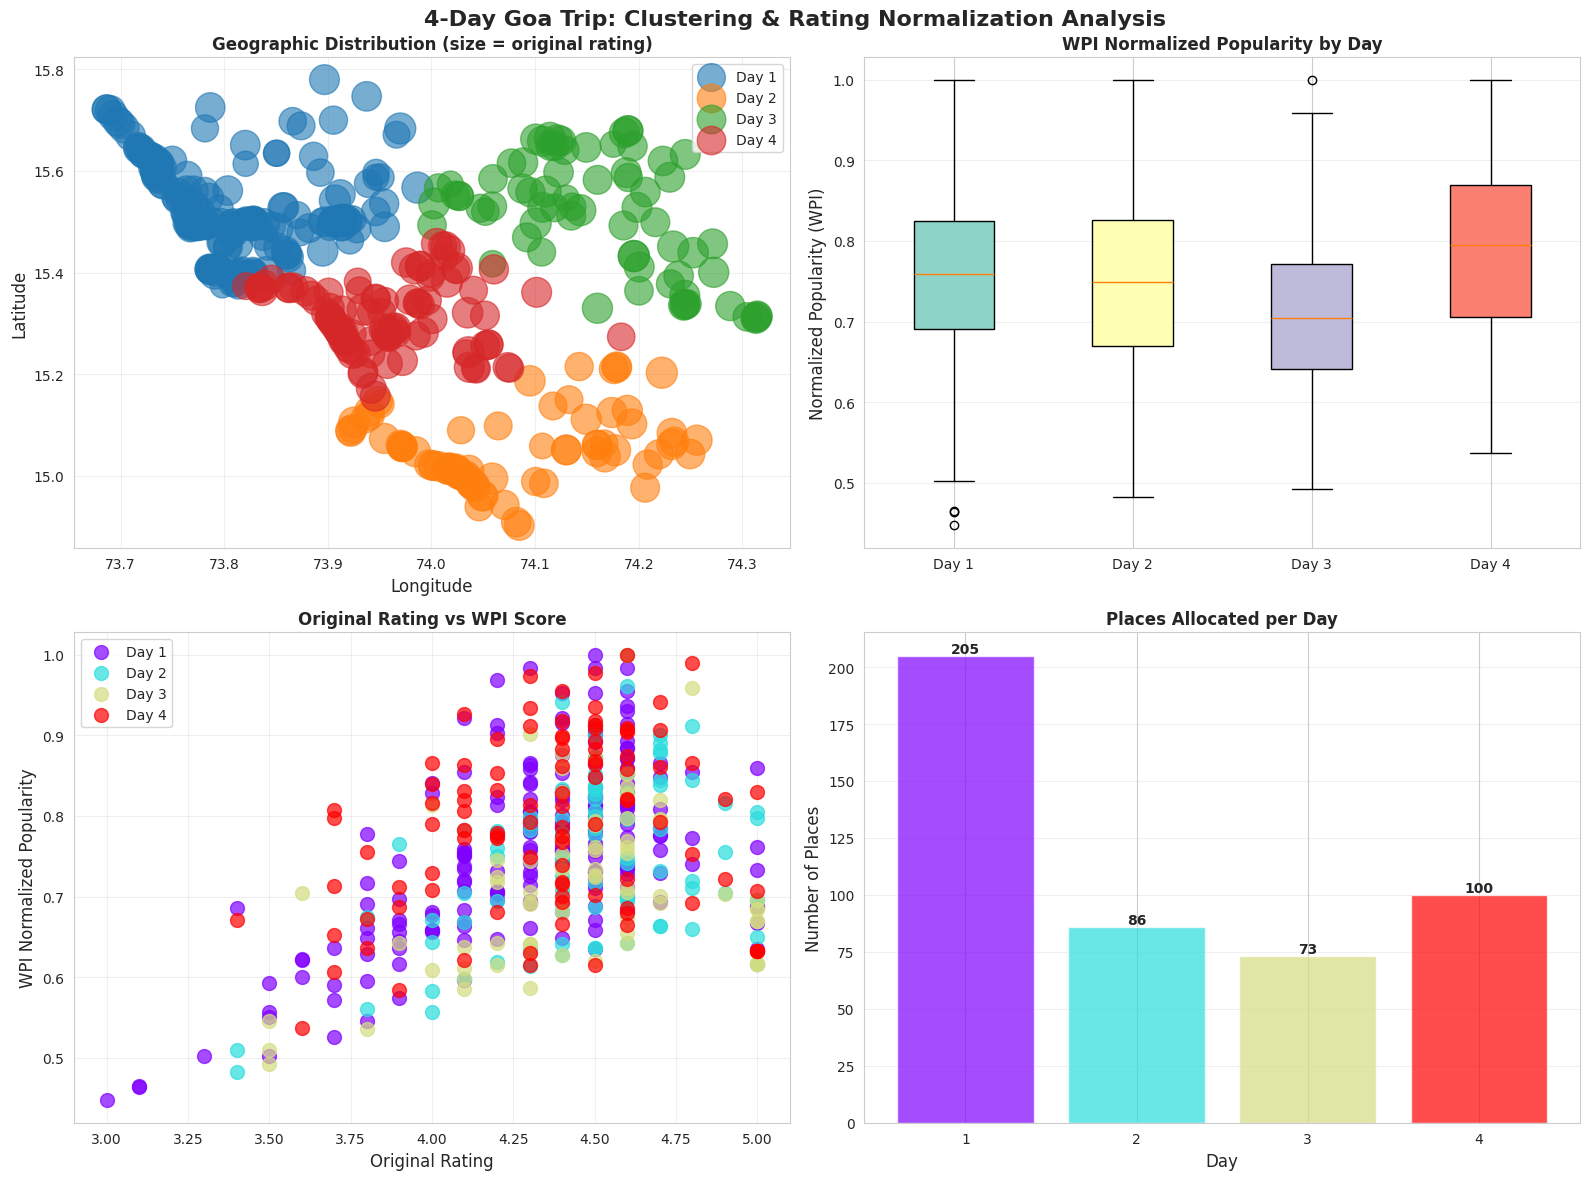

In [12]:
# Create comparison visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'{NUM_DAYS}-Day Goa Trip: Clustering & Rating Normalization Analysis', 
             fontsize=16, fontweight='bold')

# Plot 1: Original Ratings by Day
ax1 = axes[0, 0]
for day in range(1, NUM_DAYS + 1):
    day_data = df_normalized[df_normalized['day'] == day]
    ax1.scatter(day_data['longitude'], day_data['latitude'], 
               s=day_data['rating']*100, alpha=0.6, label=f'Day {day}')
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.set_title('Geographic Distribution (size = original rating)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: WPI Normalized Popularity by Day
ax2 = axes[0, 1]
day_labels = []
normalized_popularity_by_day = []
for day in range(1, NUM_DAYS + 1):
    day_data = df_normalized[df_normalized['day'] == day]
    normalized_popularity_by_day.append(day_data['normalized_popularity'].values)
    day_labels.append(f'Day {day}')

bp = ax2.boxplot(normalized_popularity_by_day, labels=day_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.Set3.colors):
    patch.set_facecolor(color)
ax2.set_ylabel('Normalized Popularity (WPI)', fontsize=12)
ax2.set_title('WPI Normalized Popularity by Day', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Original Rating vs WPI Normalized Popularity
ax3 = axes[1, 0]
colors_by_day = plt.cm.rainbow(np.linspace(0, 1, NUM_DAYS))
for day in range(1, NUM_DAYS + 1):
    day_data = df_normalized[df_normalized['day'] == day]
    ax3.scatter(day_data['rating'], day_data['normalized_popularity'],
               alpha=0.7, s=100, label=f'Day {day}', 
               color=colors_by_day[day-1])
ax3.set_xlabel('Original Rating', fontsize=12)
ax3.set_ylabel('WPI Normalized Popularity', fontsize=12)
ax3.set_title('Original Rating vs WPI Score', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Places per Day
ax4 = axes[1, 1]
day_counts = df_normalized.groupby('day').size()
bars = ax4.bar(day_counts.index, day_counts.values, color=colors_by_day, alpha=0.7)
ax4.set_xlabel('Day', fontsize=12)
ax4.set_ylabel('Number of Places', fontsize=12)
ax4.set_title('Places Allocated per Day', fontsize=12, fontweight='bold')
ax4.set_xticks(range(1, NUM_DAYS + 1))
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('module2_analysis.png', dpi=300, bbox_inches='tight')
print("\n✅ Analysis visualization saved to: module2_analysis.png")
plt.show()

---

## Next Steps

### Module 3: Route Optimization with Genetic Algorithm

Use the clustered and normalized data to:
1. **Load clusters** from `module2_clusters_for_ga.json`
2. **Optimize daily routes** using Genetic Algorithm (TTDP/OPTW problem)
3. **Generate complete itinerary** with timings and directions

### Integration with Existing Code

The exported JSON file (`module2_clusters_for_ga.json`) is compatible with:
- `kmeans_clustering.ipynb` load/save format
- Genetic Algorithm input format
- Backend API data structures

## Key Insights

1. **Rating Normalization Benefits:**
   - Fair comparison within each day's cluster
   - Accounts for varying rating distributions across regions
   - Helps GA prioritize places relative to their cluster

2. **Cluster Quality:**
   - Geographic proximity ensures efficient daily routes
   - Balanced distribution of places across days
   - Minimizes travel time between places on same day